# 6st week's homework - by [Aleksei Novikov](https://www.linkedin.com/in/devnovikov/)

## Preparation

In [199]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mutual_info_score

from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import  roc_auc_score, auc
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import KFold
from sklearn.tree import DecisionTreeRegressor
from sklearn.tree import export_text
from sklearn.ensemble import RandomForestRegressor

import seaborn as sns

import xgboost as xgb

%matplotlib inline

### Preparing the dataset

Preparation:

* Fill missing values with zeros.
* Do train/validation/test split with 60%/20%/20% distribution.
* Use the `train_test_split` function and set the `random_state` parameter to 1.
* Use `DictVectorizer(sparse=True)` to turn the dataframes into matrices.




In [200]:
df = pd.read_csv("https://raw.githubusercontent.com/alexeygrigorev/datasets/master/car_fuel_efficiency.csv")

df.columns = df.columns.str.lower().str.replace(' ', '_')
categorical_columns = list(df.dtypes[df.dtypes == 'object'].index)
numeric_columns = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])]

for col in categorical_columns:
    df[col] = df[col].str.lower().str.replace(' ', '_')

df[categorical_columns] = df[categorical_columns].fillna("NA")
df[numeric_columns] = df[numeric_columns].fillna(0.0)

df.isnull().sum()


engine_displacement    0
num_cylinders          0
horsepower             0
vehicle_weight         0
acceleration           0
model_year             0
origin                 0
fuel_type              0
drivetrain             0
num_doors              0
fuel_efficiency_mpg    0
dtype: int64

In [201]:
df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=1)
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=1)

df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

y_train = df_train.fuel_efficiency_mpg.values
y_val = df_val.fuel_efficiency_mpg.values
y_test = df_test.fuel_efficiency_mpg.values

del df_train['fuel_efficiency_mpg']
del df_val['fuel_efficiency_mpg']
del df_test['fuel_efficiency_mpg']

In [202]:
categorical_columns = list(df_train.dtypes[df_train.dtypes == 'object'].index)
numeric_columns = [c for c in df_train.columns if pd.api.types.is_numeric_dtype(df_train[c])]

In [203]:
dv = DictVectorizer(sparse=True)

train_dict = df_train[categorical_columns + numeric_columns].to_dict(orient='records')
val_dict = df_val[categorical_columns + numeric_columns].to_dict(orient='records')
test_dict = df_test[categorical_columns + numeric_columns].to_dict(orient='records')

X_train = dv.fit_transform(train_dict)
X_val = dv.transform(val_dict)
X_test = dv.transform(test_dict)

## Question 1

Let's train a decision tree regressor to predict the `fuel_efficiency_mpg` variable.

* Train a model with `max_depth=1`.


Which feature is used for splitting the data?

Answer:
* `'vehicle_weight'`

In [204]:
dt = DecisionTreeRegressor(max_depth=1)
dt.fit(X_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,1
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [205]:
print(export_text(dt, feature_names=list(dv.get_feature_names_out())))

|--- vehicle_weight <= 3022.11
|   |--- value: [16.88]
|--- vehicle_weight >  3022.11
|   |--- value: [12.94]



## Question 2

Train a random forest regressor with these parameters:

* `n_estimators=10`
* `random_state=1`
* `n_jobs=-1` (optional - to make training faster)


What's the RMSE of this model on the validation data?

Answer:
* 0.45


In [206]:
def rmse(y, y_pred):
    return np.sqrt(mean_squared_error(y, y_pred))

In [207]:
rf = RandomForestRegressor(n_estimators=10, random_state=1, n_jobs=-1)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_val)
rmse_score = rmse(y_val, y_pred)

print(f"\nQuestion 2 Answer:")
print(f"RMSE on validation data: {rmse_score:.3f}")



Question 2 Answer:
RMSE on validation data: 0.459


## Question 3

Now let's experiment with the `n_estimators` parameter

* Try different values of this parameter from 10 to 200 with step 10.
* Set `random_state` to `1`.
* Evaluate the model on the validation dataset.


After which value of `n_estimators` does RMSE stop improving?
Consider 3 decimal places for calculating the answer.

Answer:

- 200



In [208]:
n_estimators_range = range(10, 201, 10)
rmse_scores = []
for n_estimators in n_estimators_range:
    rf = RandomForestRegressor(n_estimators=n_estimators, random_state=1, n_jobs=-1)
    rf.fit(X_train, y_train)

    y_pred = rf.predict(X_val)
    rmse_score = rmse(y_val, y_pred)

    rmse_scores.append(rmse_score)

    print(f"n_estimators={n_estimators:3d}, RMSE={rmse_score:.3f}")



n_estimators= 10, RMSE=0.459
n_estimators= 20, RMSE=0.454
n_estimators= 30, RMSE=0.451
n_estimators= 40, RMSE=0.448
n_estimators= 50, RMSE=0.446
n_estimators= 60, RMSE=0.445
n_estimators= 70, RMSE=0.445
n_estimators= 80, RMSE=0.445
n_estimators= 90, RMSE=0.445
n_estimators=100, RMSE=0.445
n_estimators=110, RMSE=0.444
n_estimators=120, RMSE=0.444
n_estimators=130, RMSE=0.444
n_estimators=140, RMSE=0.444
n_estimators=150, RMSE=0.443
n_estimators=160, RMSE=0.443
n_estimators=170, RMSE=0.443
n_estimators=180, RMSE=0.443
n_estimators=190, RMSE=0.443
n_estimators=200, RMSE=0.443


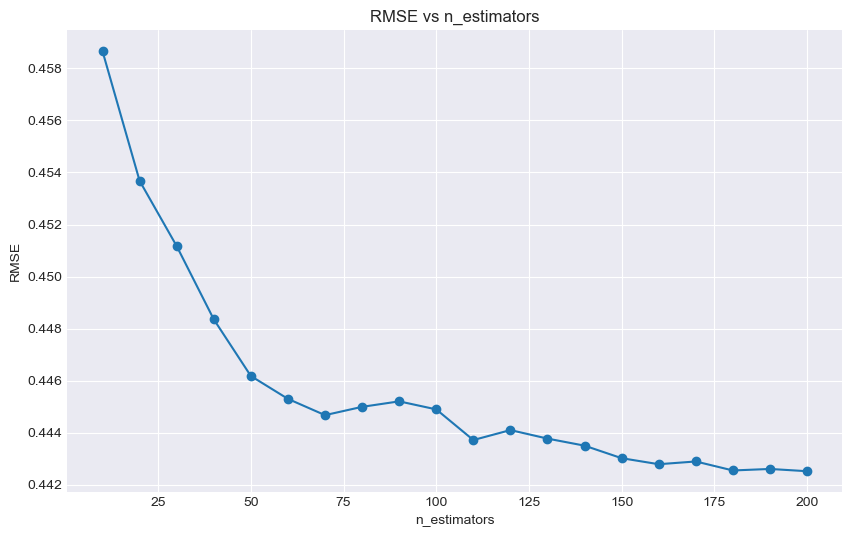


Question 3 Answer:
RMSE stops improving after n_estimators = 150
Minimum RMSE: 0.443


In [209]:
plt.figure(figsize=(10, 6))
plt.plot(n_estimators_range, rmse_scores, marker='o')
plt.xlabel('n_estimators')
plt.ylabel('RMSE')
plt.title('RMSE vs n_estimators')
plt.grid(True)
plt.show()

rmse_rounded = [round(score, 3) for score in rmse_scores]
min_rmse = min(rmse_rounded)
first_min_idx = rmse_rounded.index(min_rmse)
n_estimators_best = list(n_estimators_range)[first_min_idx]

print(f"\nQuestion 3 Answer:")
print(f"RMSE stops improving after n_estimators = {n_estimators_best}")
print(f"Minimum RMSE: {min_rmse:.3f}")

## Question 4

Let's select the best `max_depth`:

* Try different values of `max_depth`: `[10, 15, 20, 25]`
* For each of these values,
  * try different values of `n_estimators` from 10 till 200 (with step 10)
  * calculate the mean RMSE
* Fix the random seed: `random_state=1`


What's the best `max_depth`, using the mean RMSE?

Answer:
* 10


In [210]:
n_estimators_range = range(10, 201, 10)
max_depth_values = [10, 15, 20, 25]

scores = []
for max_depth in max_depth_values:
    for n_estimators in n_estimators_range:
        rf = RandomForestRegressor(n_estimators=n_estimators, max_depth=max_depth, random_state=1, n_jobs=-1)
        rf.fit(X_train, y_train)

        y_pred = rf.predict(X_val)
        rmse_score = rmse(y_val, y_pred)
        scores.append((max_depth, n_estimators, rmse_score))
        print(f"d={max_depth:3d}, n_estimators={n_estimators:3d}, RMSE={rmse_score:.3f}")


d= 10, n_estimators= 10, RMSE=0.451
d= 10, n_estimators= 20, RMSE=0.447
d= 10, n_estimators= 30, RMSE=0.446
d= 10, n_estimators= 40, RMSE=0.443
d= 10, n_estimators= 50, RMSE=0.442
d= 10, n_estimators= 60, RMSE=0.442
d= 10, n_estimators= 70, RMSE=0.441
d= 10, n_estimators= 80, RMSE=0.442
d= 10, n_estimators= 90, RMSE=0.442
d= 10, n_estimators=100, RMSE=0.441
d= 10, n_estimators=110, RMSE=0.441
d= 10, n_estimators=120, RMSE=0.441
d= 10, n_estimators=130, RMSE=0.441
d= 10, n_estimators=140, RMSE=0.440
d= 10, n_estimators=150, RMSE=0.440
d= 10, n_estimators=160, RMSE=0.440
d= 10, n_estimators=170, RMSE=0.440
d= 10, n_estimators=180, RMSE=0.440
d= 10, n_estimators=190, RMSE=0.440
d= 10, n_estimators=200, RMSE=0.440
d= 15, n_estimators= 10, RMSE=0.458
d= 15, n_estimators= 20, RMSE=0.453
d= 15, n_estimators= 30, RMSE=0.451
d= 15, n_estimators= 40, RMSE=0.448
d= 15, n_estimators= 50, RMSE=0.446
d= 15, n_estimators= 60, RMSE=0.445
d= 15, n_estimators= 70, RMSE=0.445
d= 15, n_estimators= 80, RMS

In [211]:
columns = ['max_depth', 'n_estimators', 'rmse']
df_scores = pd.DataFrame(scores, columns=columns)
df_scores

,max_depth,n_estimators,rmse
0,10,10,0.450627
1,10,20,0.447109
2,10,30,0.445616
3,10,40,0.443237
4,10,50,0.442072
...,...,...,...
75,25,160,0.442814
76,25,170,0.442889
77,25,180,0.442600
78,25,190,0.442709


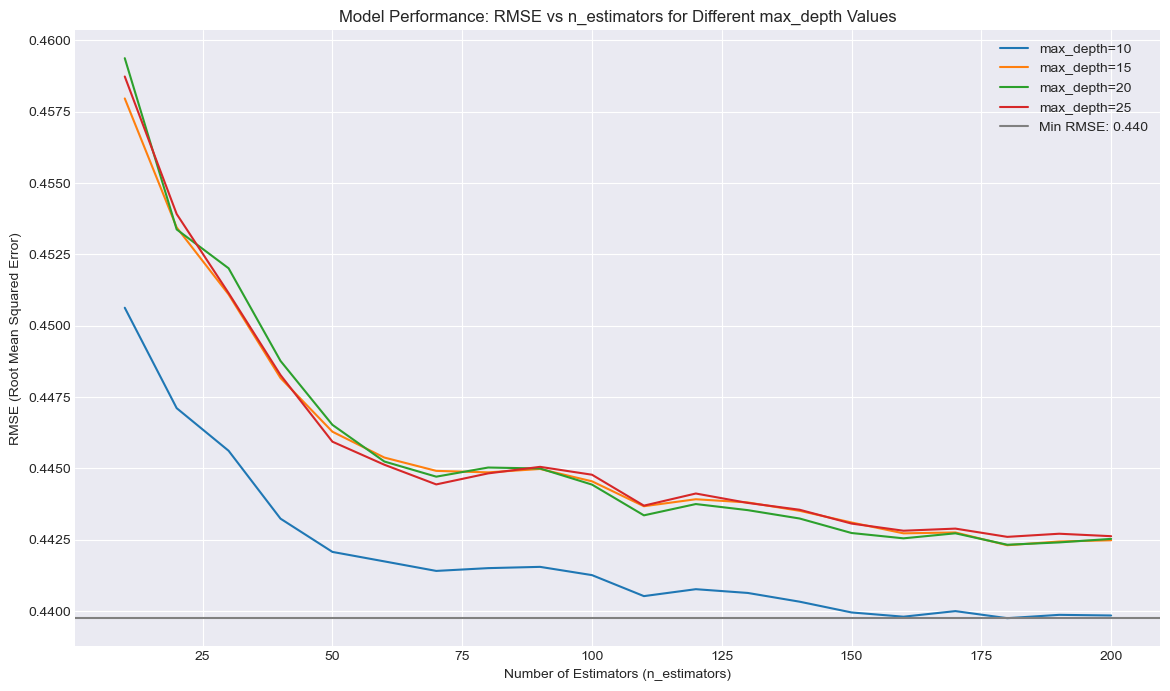

depth=10: Min RMSE=0.43975
depth=15: Min RMSE=0.44231
depth=20: Min RMSE=0.44232
depth=25: Min RMSE=0.44260


In [212]:
plt.figure(figsize=(14, 8))

for i, d in enumerate(max_depth_values):
    df_subset = df_scores[df_scores.max_depth == d]
    
    plt.plot(df_subset.n_estimators, df_subset.rmse,
             label=f'max_depth={d}')

min_rmse_overall = df_scores.rmse.min()
plt.axhline(y=min_rmse_overall, color='gray', label=f'Min RMSE: {min_rmse_overall:.3f}')

plt.xlabel('Number of Estimators (n_estimators)')
plt.ylabel('RMSE (Root Mean Squared Error)')
plt.title('Model Performance: RMSE vs n_estimators for Different max_depth Values')

plt.legend(loc='upper right')

plt.grid(True)

plt.show()


for d in max_depth_values:
    df_subset = df_scores[df_scores.max_depth == d]
    min_rmse = df_subset.rmse.min()
    print(f"depth={d:2d}: Min RMSE={min_rmse:.5f}")

# Question 5

We can extract feature importance information from tree-based models.

At each step of the decision tree learning algorithm, it finds the best split.
When doing it, we can calculate "gain" - the reduction in impurity before and after the split.
This gain is quite useful in understanding what are the important features for tree-based models.

In Scikit-Learn, tree-based models contain this information in the
[`feature_importances_`](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html#sklearn.ensemble.RandomForestRegressor.feature_importances_)
field.

For this homework question, we'll find the most important feature:

* Train the model with these parameters:
  * `n_estimators=10`,
  * `max_depth=20`,
  * `random_state=1`,
  * `n_jobs=-1` (optional)
* Get the feature importance information from this model


What's the most important feature (among these 4)?

Answer:
* `vehicle_weight`


In [213]:
rf = RandomForestRegressor(n_estimators=10, max_depth=20, random_state=1, n_jobs=-1)
rf.fit(X_train, y_train)

feature_importances = rf.feature_importances_
feature_names = dv.get_feature_names_out()

importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importances
}).sort_values('importance', ascending=False)

importance_df.head()

,feature,importance
13,vehicle_weight,0.959153
6,horsepower,0.016066
0,acceleration,0.011490
3,engine_displacement,0.003279
7,model_year,0.003170


In [214]:
target_features = ['vehicle_weight', 'horsepower', 'acceleration', 'engine_displacement']

for feature in target_features:
    importance = importance_df[importance_df['feature'] == feature]['importance'].values
    print(f"{feature}: {importance[0]:.6f}")

target_feature_df = importance_df[importance_df['feature'].isin(target_features)].sort_values('importance', ascending=False)
print(f"\nMost important feature: {target_feature_df.iloc[0].feature} with importance: {target_feature_df.iloc[0]['importance']}")

vehicle_weight: 0.959153
horsepower: 0.016066
acceleration: 0.011490
engine_displacement: 0.003279

Most important feature: vehicle_weight with importance: 0.9591531737242687


## Question 6

Now let's train an XGBoost model! For this question, we'll tune the `eta` parameter:

* Install XGBoost
* Create DMatrix for train and validation
* Create a watchlist
* Train a model with these parameters for 100 rounds:

```
xgb_params = {
    'eta': 0.3,
    'max_depth': 6,
    'min_child_weight': 1,

    'objective': 'reg:squarederror',
    'nthread': 8,

    'seed': 1,
    'verbosity': 1,
}
```

Now change `eta` from `0.3` to `0.1`.

Which eta leads to the best RMSE score on the validation dataset?

Answer:
* 0.1


In [217]:
features = list(dv.get_feature_names_out())
dtrain = xgb.DMatrix(X_train, label=y_train, feature_names=features)
dval = xgb.DMatrix(X_val, label=y_val, feature_names=features)

watchlist = [(dtrain, 'train'), (dval, 'val')]

In [221]:
xgb_params_eta_03 = {
    'eta': 0.3,
    'max_depth': 6,
    'min_child_weight': 1,

    'objective': 'reg:squarederror',
    'nthread': 8,

    'seed': 1,
    'verbosity': 1,
}

model_eta_03 = xgb.train(xgb_params_eta_03, dtrain, evals=watchlist, num_boost_round=100)

y_pred_eta_03 = model_eta_03.predict(dval)
rmse_eta_03 = rmse(y_val, y_pred_eta_03)
print(f"Final RMSE with eta=0.3: {rmse_eta_03:.4f}")

[0]	train-rmse:1.81393	val-rmse:1.85444
[1]	train-rmse:1.31919	val-rmse:1.35353
[2]	train-rmse:0.98120	val-rmse:1.01316
[3]	train-rmse:0.75443	val-rmse:0.78667
[4]	train-rmse:0.60680	val-rmse:0.64318
[5]	train-rmse:0.51381	val-rmse:0.55664
[6]	train-rmse:0.45470	val-rmse:0.50321
[7]	train-rmse:0.41881	val-rmse:0.47254
[8]	train-rmse:0.39534	val-rmse:0.45509
[9]	train-rmse:0.38038	val-rmse:0.44564
[10]	train-rmse:0.37115	val-rmse:0.43896
[11]	train-rmse:0.36361	val-rmse:0.43594
[12]	train-rmse:0.35850	val-rmse:0.43558
[13]	train-rmse:0.35365	val-rmse:0.43394
[14]	train-rmse:0.35025	val-rmse:0.43349
[15]	train-rmse:0.34666	val-rmse:0.43362
[16]	train-rmse:0.34459	val-rmse:0.43378
[17]	train-rmse:0.34128	val-rmse:0.43405
[18]	train-rmse:0.33822	val-rmse:0.43391
[19]	train-rmse:0.33709	val-rmse:0.43374
[20]	train-rmse:0.33553	val-rmse:0.43376
[21]	train-rmse:0.33243	val-rmse:0.43453
[22]	train-rmse:0.33031	val-rmse:0.43510
[23]	train-rmse:0.32815	val-rmse:0.43601
[24]	train-rmse:0.32670	va

In [222]:
xgb_params_eta_01 = {
    'eta': 0.1,
    'max_depth': 6,
    'min_child_weight': 1,

    'objective': 'reg:squarederror',
    'nthread': 8,

    'seed': 1,
    'verbosity': 1,
}

model_eta_01 = xgb.train(xgb_params_eta_01, dtrain, evals=watchlist, num_boost_round=100)

y_pred_eta_01 = model_eta_01.predict(dval)
rmse_eta_01 = rmse(y_val, y_pred_eta_01)
print(f"Final RMSE with eta=0.1: {rmse_eta_01:.4f}")

[0]	train-rmse:2.28944	val-rmse:2.34561
[1]	train-rmse:2.07396	val-rmse:2.12434
[2]	train-rmse:1.88066	val-rmse:1.92597
[3]	train-rmse:1.70730	val-rmse:1.74987
[4]	train-rmse:1.55163	val-rmse:1.59059
[5]	train-rmse:1.41247	val-rmse:1.44988
[6]	train-rmse:1.28796	val-rmse:1.32329
[7]	train-rmse:1.17660	val-rmse:1.20930
[8]	train-rmse:1.07736	val-rmse:1.10830
[9]	train-rmse:0.98883	val-rmse:1.02009
[10]	train-rmse:0.91008	val-rmse:0.94062
[11]	train-rmse:0.84030	val-rmse:0.87100
[12]	train-rmse:0.77874	val-rmse:0.80916
[13]	train-rmse:0.72417	val-rmse:0.75465
[14]	train-rmse:0.67626	val-rmse:0.70780
[15]	train-rmse:0.63402	val-rmse:0.66672
[16]	train-rmse:0.59690	val-rmse:0.63062
[17]	train-rmse:0.56447	val-rmse:0.60016
[18]	train-rmse:0.53619	val-rmse:0.57383
[19]	train-rmse:0.51138	val-rmse:0.55044
[20]	train-rmse:0.48983	val-rmse:0.53064
[21]	train-rmse:0.47135	val-rmse:0.51451
[22]	train-rmse:0.45501	val-rmse:0.49998
[23]	train-rmse:0.44120	val-rmse:0.48790
[24]	train-rmse:0.42929	va

In [223]:
# Compare results
print(f"\nQuestion 6 Answer:")
print(f"\nRMSE Comparison:")
print(f"eta=0.3: {rmse_eta_03:.4f}")
print(f"eta=0.1: {rmse_eta_01:.4f}")
print(f"\nDifference: {abs(rmse_eta_03 - rmse_eta_01):.4f}")

if rmse_eta_03 < rmse_eta_01:
    print("\nBest eta: 0.3")
elif rmse_eta_01 < rmse_eta_03:
    print("\nBest eta: 0.1")
else:
    print("\nBoth give equal value")


Question 6 Answer:

RMSE Comparison:
eta=0.3: 0.4502
eta=0.1: 0.4262

Difference: 0.0239

Best eta: 0.1
